In [ ]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("default")

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "figure.edgecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#1f1f1f",
        "axes.labelcolor": "#1f1f1f",
        "axes.titlecolor": "#1f1f1f",
        "xtick.color": "#1f1f1f",
        "ytick.color": "#1f1f1f",
        "text.color": "#1f1f1f",
        "grid.color": "#b8b8b8",
        "grid.alpha": 0.45,
        "grid.linestyle": "-",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "savefig.transparent": False,
    }
)

try:
    from IPython import get_ipython

    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic(
            "config",
            "InlineBackend.print_figure_kwargs = {'facecolor': 'white', 'edgecolor': 'white'}",
        )
except Exception:
    pass

data_path = Path("../Input data/Newcastle_Urban_Case_meta_updated.csv")
if not data_path.exists():
    data_path = Path("Input data/Newcastle_Urban_Case_meta_updated.csv")

meta = pd.read_csv(data_path)
n_dwellings = len(meta)

occupant_counts = (
    pd.to_numeric(meta["No_occupants"], errors="coerce")
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

building_col = "House_Form" if "House_Form" in meta.columns else "House_Type"
building_counts = meta[building_col].fillna("Unknown").value_counts().sort_index()

occ_palette = ["#1f77b4", "#2a9d8f", "#4c78a8", "#f4a261", "#e76f51", "#8da0cb", "#66c2a5"]
bld_palette = ["#2f4b7c", "#4e79a7", "#59a14f", "#f28e2b", "#e15759", "#76b7b2", "#edc948"]
occ_colors = occ_palette[: len(occupant_counts)]
bld_colors = bld_palette[: len(building_counts)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor="white")
fig.patch.set_facecolor("white")
fig.patch.set_edgecolor("white")
fig.patch.set_alpha(1.0)
plt.subplots_adjust(wspace=0.25, hspace=0.35)
for ax in axes.flat:
    ax.set_facecolor("white")
    ax.patch.set_alpha(1.0)
    ax.tick_params(colors="#1f1f1f")
    for spine in ax.spines.values():
        spine.set_color("#1f1f1f")

axes[0, 0].bar(
    occupant_counts.index.astype(str),
    occupant_counts.values,
    color=occ_colors,
    edgecolor="#2b2b2b",
    linewidth=0.6,
)
axes[0, 0].set_title("Occupants per Dwelling (Bar)")
axes[0, 0].set_xlabel("Number of Occupants")
axes[0, 0].set_ylabel("Number of Dwellings")
axes[0, 0].grid(axis="y")

axes[0, 1].pie(
    occupant_counts.values,
    labels=occupant_counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    colors=occ_colors,
    textprops={"color": "#1f1f1f"},
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
axes[0, 1].set_title("Occupants per Dwelling (Pie)")
axes[0, 1].axis("equal")

axes[1, 0].bar(
    building_counts.index.astype(str),
    building_counts.values,
    color=bld_colors,
    edgecolor="#2b2b2b",
    linewidth=0.6,
)
axes[1, 0].set_title(f"{building_col} Distribution (Bar)")
axes[1, 0].set_xlabel(building_col)
axes[1, 0].set_ylabel("Number of Dwellings")
axes[1, 0].tick_params(axis="x", rotation=20)
axes[1, 0].grid(axis="y")

axes[1, 1].pie(
    building_counts.values,
    labels=building_counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    colors=bld_colors,
    textprops={"color": "#1f1f1f"},
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
axes[1, 1].set_title(f"{building_col} Distribution (Pie)")
axes[1, 1].axis("equal")

fig.suptitle(f"Dwelling Characteristics (n={n_dwellings})", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [20]:
from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- Editable inputs -------------------------------------------------------
cwd = Path.cwd()
repo_root = cwd if (cwd / "Output Data").exists() else cwd.parent
result_case_dir = (
    repo_root
    / "Output Data"
    / "Single Dwelling Runs"
    / "offset_2h_winter_7d_case"
    / "agile_hybrid_EV_5kW_offset2p0h"
)
single_dwelling_id = 55
single_run_id = None  # None uses the first available run.
aggregate_run_ids = None  # None uses all runs common to every dwelling file.
aggregate_max_runs = None
aggregate_max_dwellings = None  # Set to a small number while drafting if the full cache is slow.
only_optimal = True
comfort_tolerance_C = 1.0
comfort_high_start_hour = 8
comfort_high_end_hour = 21
plot_comfort_constraint_high_periods_only = True
include_flex_setpoint = False
save_single_dwelling_figure = True
save_aggregate_figure = False
single_dwelling_figure_dir = repo_root / "Output Data" / "plots" / "single dwelling plot"
aggregate_figure_dir = repo_root / "Output Data" / "plots"
single_case_label = "HHP"
single_offset_label = "2hroffset"
single_ev_label = "EV5kW"
single_dwelling_figure_filename = f"dwelling{single_dwelling_id}_{single_case_label}_{single_offset_label}_{single_ev_label}.png"

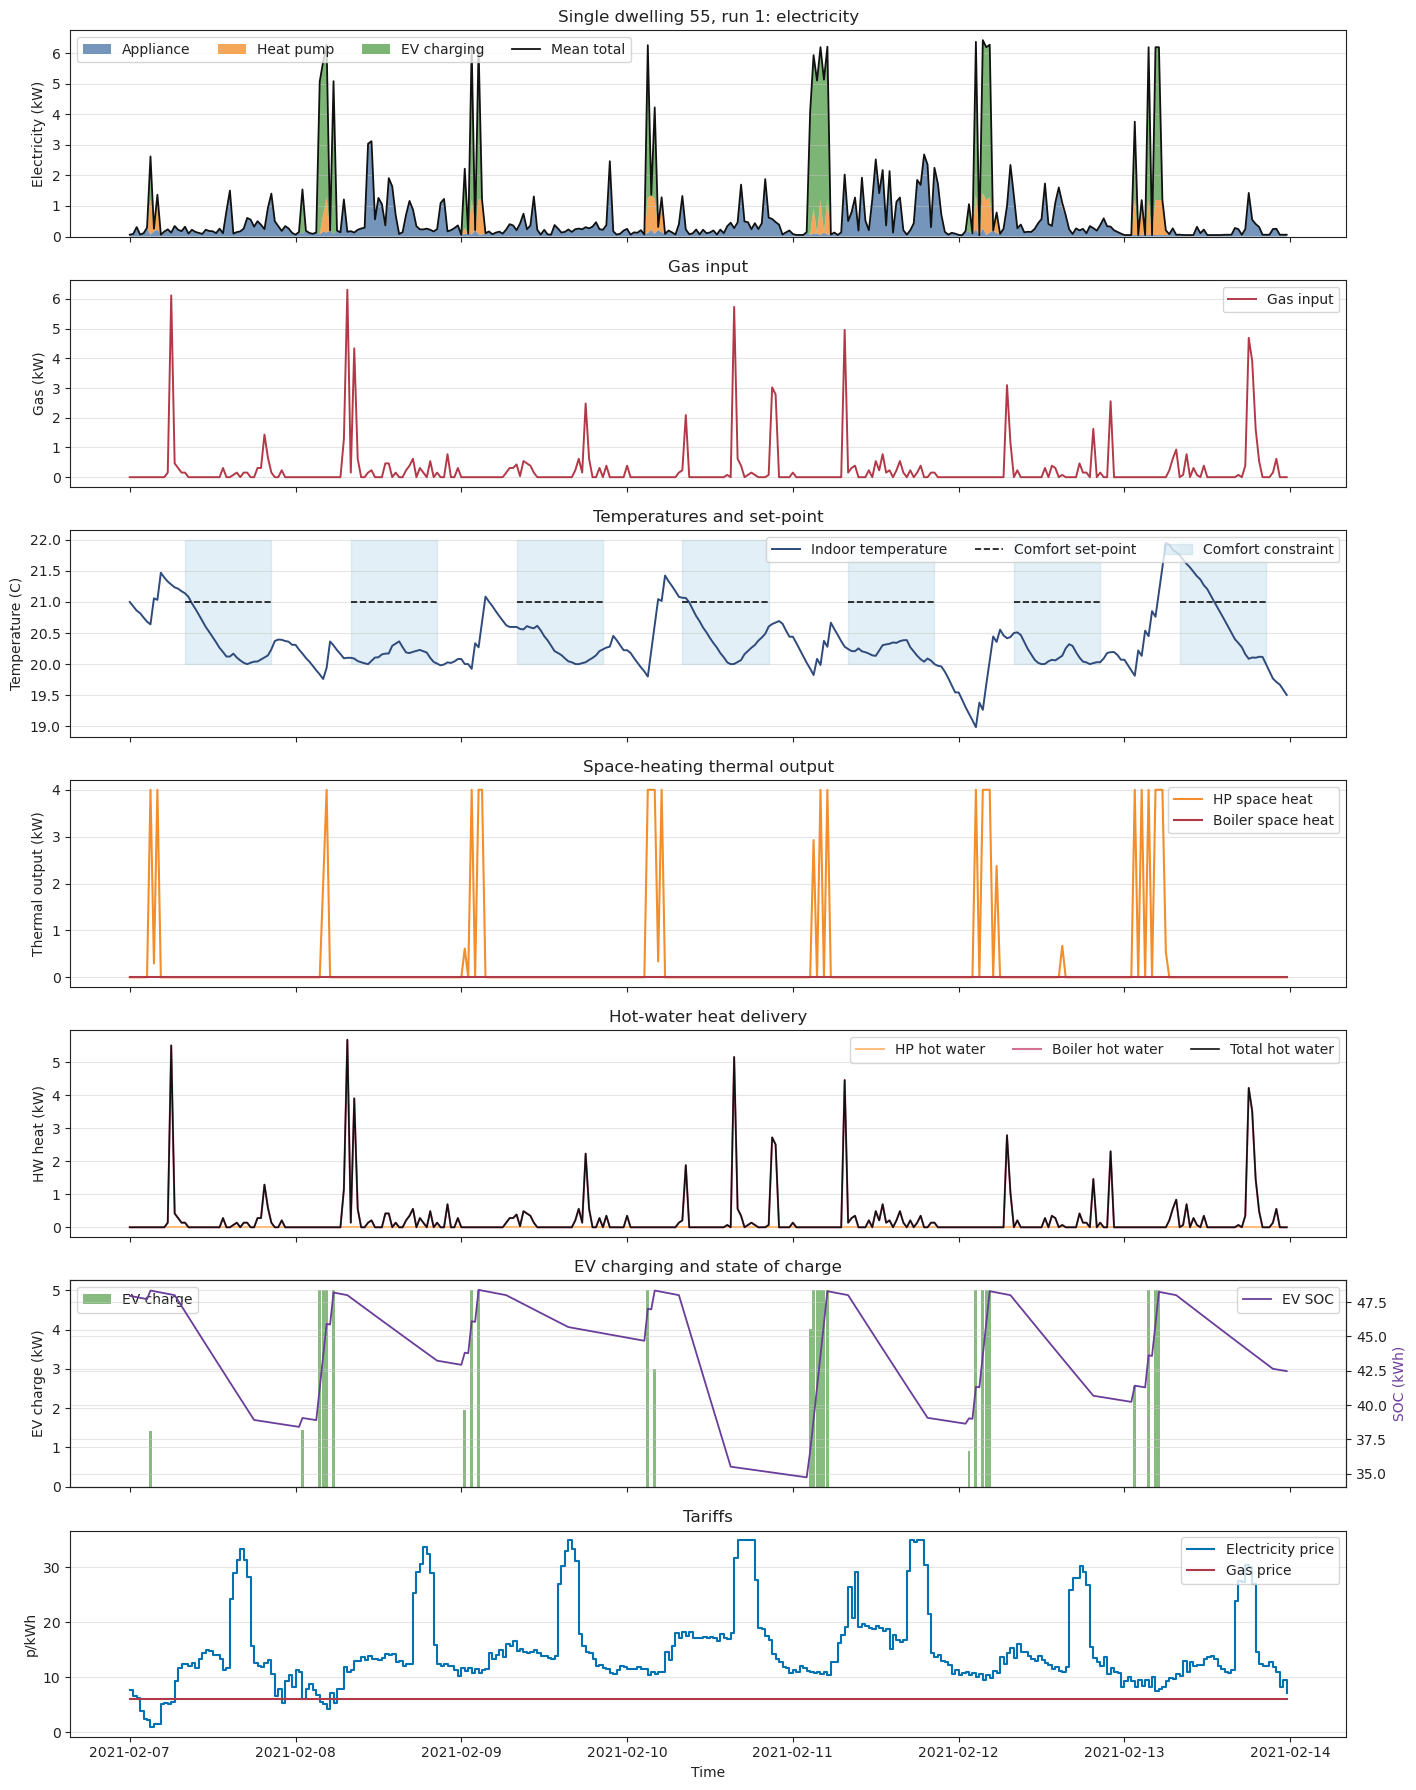

{'file': 'E:\\GitHubProjects\\LV network\\Output Data\\Single Dwelling Runs\\offset_2h_winter_7d_case\\agile_hybrid_EV_5kW_offset2p0h\\dwelling_55_runs_breakdown.csv',
 'run': 1,
 'figure': 'E:\\GitHubProjects\\LV network\\Output Data\\plots\\single dwelling plot\\dwelling55_HHP_2hroffset_EV5kW.png'}

In [21]:

# ---- White-background plotting style --------------------------------------
mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("default")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "figure.edgecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#222222",
        "axes.labelcolor": "#222222",
        "axes.titlecolor": "#222222",
        "xtick.color": "#222222",
        "ytick.color": "#222222",
        "text.color": "#222222",
        "grid.color": "#c7c7c7",
        "grid.alpha": 0.45,
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "savefig.transparent": False,
    }
)

COLORS = {
    "appliance": "#4E79A7",
    "hp": "#F28E2B",
    "ev": "#59A14F",
    "gas": "#B23A48",
    "total": "#111111",
    "tin": "#2F4B7C",
    "tank": "#8C564B",
    "band": "#A6CEE3",
    "hp_hw": "#FFBE7D",
    "bo_hw": "#D37295",
    "soc": "#6A3D9A",
    "price": "#0072B2",
}

DATA_COLS = [
    "hp_elec_kw",
    "boiler_gas_kw",
    "ev_charge_kw",
    "appliance_kw",
    "Tin_C",
    "T_tank_C",
    "T_set",
    "T_low",
    "T_high",
    "Q_hp_space_w",
    "Q_bo_space_w",
    "Q_hp_hw_w",
    "Q_bo_hw_w",
    "ev_soc_kwh",
    "tariff_elec_price",
    "tariff_gas_price",
]
SUM_COLS = ["hp_elec_kw", "boiler_gas_kw", "ev_charge_kw", "appliance_kw", "Q_hp_space_w", "Q_bo_space_w", "Q_hp_hw_w", "Q_bo_hw_w"]
MEAN_COLS = ["Tin_C", "T_tank_C", "T_set", "T_low", "T_high", "ev_soc_kwh", "tariff_elec_price", "tariff_gas_price"]

def natural_key(path):
    return [int(part) if part.isdigit() else part for part in re.split(r"(\d+)", str(path))]

def clean_axes(ax):
    ax.set_facecolor("white")
    ax.tick_params(colors="#222222")
    for spine in ax.spines.values():
        spine.set_color("#222222")
    ax.grid(True, axis="y")

def read_breakdown(path):
    wanted = set(DATA_COLS + ["time", "run", "dwelling_id", "solve_status"])
    df = pd.read_csv(path, usecols=lambda col: col in wanted)
    if "time" not in df.columns or "run" not in df.columns:
        raise ValueError(f"Missing time/run columns in {path}")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.dropna(subset=["time"]).copy()
    df["run"] = pd.to_numeric(df["run"], errors="coerce")
    df = df.dropna(subset=["run"]).copy()
    df["run"] = df["run"].astype(int)
    if only_optimal and "solve_status" in df.columns:
        df = df[df["solve_status"].astype(str).str.lower().eq("optimal")].copy()
    for col in SUM_COLS:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    for col in MEAN_COLS:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.sort_values(["run", "time"])

def setpoint_band(time_index, frame=None):
    hours = time_index.hour + time_index.minute / 60.0
    high_temp_mask = (hours >= comfort_high_start_hour) & (hours < comfort_high_end_hour)
    if frame is not None and {"T_set", "T_low", "T_high"}.issubset(frame.columns):
        vals = frame[["T_set", "T_low", "T_high"]].apply(pd.to_numeric, errors="coerce")
        if vals["T_set"].notna().any():
            t_set = vals["T_set"].to_numpy(dtype=float)
            t_low = vals["T_low"].to_numpy(dtype=float)
            t_high = vals["T_high"].to_numpy(dtype=float)
            if plot_comfort_constraint_high_periods_only:
                t_set = np.where(high_temp_mask, t_set, np.nan)
                t_low = np.where(high_temp_mask, t_low, np.nan)
                t_high = np.where(high_temp_mask, t_high, np.nan)
            return t_set, t_low, t_high
    comfort = np.where(high_temp_mask, 21.0, 17.0)
    sequences = [comfort]
    if include_flex_setpoint:
        flex = np.where(((hours >= 6) & (hours < 8)) | ((hours >= 18) & (hours < 21)), 20.0, 16.0)
        sequences.append(flex)
    stack = np.vstack(sequences)
    t_set = stack.mean(axis=0)
    t_low = stack.min(axis=0) - comfort_tolerance_C
    t_high = stack.max(axis=0) + comfort_tolerance_C
    if plot_comfort_constraint_high_periods_only:
        t_set = np.where(high_temp_mask, t_set, np.nan)
        t_low = np.where(high_temp_mask, t_low, np.nan)
        t_high = np.where(high_temp_mask, t_high, np.nan)
    return t_set, t_low, t_high

def frame_to_dataset(run_df, title):
    t = pd.DatetimeIndex(run_df.index)
    data = {col: run_df[col].to_numpy(dtype=float)[None, :] for col in DATA_COLS}
    data["time"] = t
    data["title"] = title
    data["runs"] = 1
    data["dwellings"] = 1
    return data

def load_single_dataset(case_dir, dwelling_id, run_id=None):
    path = Path(case_dir) / f"dwelling_{dwelling_id}_runs_breakdown.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    df = read_breakdown(path)
    runs = sorted(df["run"].unique())
    selected_run = runs[0] if run_id is None else int(run_id)
    if selected_run not in runs:
        raise ValueError(f"Run {selected_run} not found. Available runs: {runs[:10]}")
    run_df = df[df["run"].eq(selected_run)].sort_values("time").set_index("time")
    return frame_to_dataset(run_df, f"Single dwelling {dwelling_id}, run {selected_run}"), {"file": str(path), "run": selected_run}

def load_aggregate_dataset(case_dir):
    files = sorted(Path(case_dir).glob("dwelling_*_runs_breakdown.csv"), key=natural_key)
    if aggregate_max_dwellings is not None:
        files = files[: int(aggregate_max_dwellings)]
    if not files:
        raise FileNotFoundError(f"No dwelling breakdown files found in {case_dir}")

    dwelling_maps = []
    common_runs = None
    time_index = None
    for path in files:
        df = read_breakdown(path)
        run_map = {}
        for run, run_df in df.groupby("run"):
            run_df = run_df.sort_values("time").set_index("time")
            if time_index is None:
                time_index = pd.DatetimeIndex(run_df.index)
            elif not pd.DatetimeIndex(run_df.index).equals(time_index):
                raise ValueError(f"Time index mismatch in {path}, run {run}")
            run_map[int(run)] = run_df
        run_set = set(run_map)
        common_runs = run_set if common_runs is None else common_runs & run_set
        dwelling_maps.append(run_map)

    selected_runs = sorted(common_runs or [])
    if aggregate_run_ids is not None:
        selected_runs = [int(r) for r in aggregate_run_ids if int(r) in selected_runs]
    if aggregate_max_runs is not None:
        selected_runs = selected_runs[: int(aggregate_max_runs)]
    if not selected_runs:
        raise ValueError("No common aggregate runs selected.")

    n_runs, n_steps = len(selected_runs), len(time_index)
    data = {col: np.zeros((n_runs, n_steps), dtype=float) for col in SUM_COLS}
    sums = {col: np.zeros((n_runs, n_steps), dtype=float) for col in MEAN_COLS}
    counts = {col: np.zeros((n_runs, n_steps), dtype=float) for col in MEAN_COLS}

    for i, run in enumerate(selected_runs):
        for run_map in dwelling_maps:
            run_df = run_map[run].reindex(time_index)
            for col in SUM_COLS:
                data[col][i] += pd.to_numeric(run_df[col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
            for col in MEAN_COLS:
                vals = pd.to_numeric(run_df[col], errors="coerce").to_numpy(dtype=float)
                mask = np.isfinite(vals)
                sums[col][i, mask] += vals[mask]
                counts[col][i, mask] += 1.0
    for col in MEAN_COLS:
        data[col] = np.divide(sums[col], counts[col], out=np.full_like(sums[col], np.nan), where=counts[col] > 0)

    data["time"] = time_index
    data["title"] = f"Aggregate: {len(files)} dwellings, {len(selected_runs)} runs"
    data["runs"] = len(selected_runs)
    data["dwellings"] = len(files)
    return data, {"case_dir": str(case_dir), "runs": selected_runs, "dwellings": len(files)}

def curve(arr):
    return np.nanmean(arr, axis=0)

def pband(arr, low=10, high=90):
    return np.nanpercentile(arr, [low, high], axis=0)

def plot_dataset(data, output_path=None):
    t = data["time"]
    t_set, t_low, t_high = setpoint_band(t, None)
    total_e = data["appliance_kw"] + data["hp_elec_kw"] + data["ev_charge_kw"]

    fig, axes = plt.subplots(7, 1, figsize=(14, 18), sharex=True, facecolor="white")
    fig.patch.set_facecolor("white")
    fig.patch.set_alpha(1.0)

    axes[0].stackplot(
        t,
        curve(data["appliance_kw"]),
        curve(data["hp_elec_kw"]),
        curve(data["ev_charge_kw"]),
        labels=["Appliance", "Heat pump", "EV charging"],
        colors=[COLORS["appliance"], COLORS["hp"], COLORS["ev"]],
        alpha=0.78,
    )
    axes[0].plot(t, curve(total_e), color=COLORS["total"], lw=1.3, label="Mean total")
    if data["runs"] > 1:
        lo, hi = pband(total_e)
        axes[0].fill_between(t, lo, hi, color="#777777", alpha=0.18, label="P10-P90 total")
    axes[0].set_ylabel("Electricity (kW)")
    axes[0].set_title(data["title"] + ": electricity")
    axes[0].legend(loc="upper left", ncol=5)

    axes[1].plot(t, curve(data["boiler_gas_kw"]), color=COLORS["gas"], lw=1.4, label="Gas input")
    if data["runs"] > 1:
        lo, hi = pband(data["boiler_gas_kw"])
        axes[1].fill_between(t, lo, hi, color=COLORS["gas"], alpha=0.18, label="P10-P90 gas")
    axes[1].set_ylabel("Gas (kW)")
    axes[1].set_title("Gas input")
    axes[1].legend(loc="upper right")

    axes[2].plot(t, curve(data["Tin_C"]), color=COLORS["tin"], lw=1.4, label="Indoor temperature")
    if data["runs"] > 1 and np.isfinite(data["Tin_C"]).any():
        lo, hi = pband(data["Tin_C"])
        axes[2].fill_between(t, lo, hi, color=COLORS["tin"], alpha=0.14, label="P10-P90 indoor temp")
    if np.isfinite(data["T_tank_C"]).any():
        axes[2].plot(t, curve(data["T_tank_C"]), color=COLORS["tank"], lw=1.1, label="Tank temperature")
    axes[2].plot(t, t_set, color=COLORS["total"], ls="--", lw=1.2, label="Comfort set-point")
    axes[2].fill_between(t, t_low, t_high, color=COLORS["band"], alpha=0.32, label="Comfort constraint")
    axes[2].set_ylabel("Temperature (C)")
    axes[2].set_title("Temperatures and set-point")
    axes[2].legend(loc="upper right", ncol=4)

    axes[3].plot(t, curve(data["Q_hp_space_w"]) / 1000, color=COLORS["hp"], label="HP space heat")
    axes[3].plot(t, curve(data["Q_bo_space_w"]) / 1000, color=COLORS["gas"], label="Boiler space heat")
    axes[3].set_ylabel("Thermal output (kW)")
    axes[3].set_title("Space-heating thermal output")
    axes[3].legend(loc="upper right")

    axes[4].plot(t, curve(data["Q_hp_hw_w"]) / 1000, color=COLORS["hp_hw"], label="HP hot water")
    axes[4].plot(t, curve(data["Q_bo_hw_w"]) / 1000, color=COLORS["bo_hw"], label="Boiler hot water")
    axes[4].plot(t, (curve(data["Q_hp_hw_w"]) + curve(data["Q_bo_hw_w"])) / 1000, color=COLORS["total"], lw=1.2, label="Total hot water")
    axes[4].set_ylabel("HW heat (kW)")
    axes[4].set_title("Hot-water heat delivery")
    axes[4].legend(loc="upper right", ncol=3)

    axes[5].bar(t, curve(data["ev_charge_kw"]), width=0.018, color=COLORS["ev"], alpha=0.72, label="EV charge")
    soc_ax = axes[5].twinx()
    if np.isfinite(data["ev_soc_kwh"]).any():
        soc_ax.plot(t, curve(data["ev_soc_kwh"]), color=COLORS["soc"], lw=1.3, label="EV SOC")
    axes[5].set_ylabel("EV charge (kW)")
    soc_ax.set_ylabel("SOC (kWh)", color=COLORS["soc"])
    axes[5].set_title("EV charging and state of charge")
    axes[5].legend(loc="upper left")
    soc_ax.legend(loc="upper right")
    clean_axes(soc_ax)

    if np.isfinite(data["tariff_elec_price"]).any():
        axes[6].step(t, curve(data["tariff_elec_price"]), where="post", color=COLORS["price"], label="Electricity price")
    if np.isfinite(data["tariff_gas_price"]).any():
        axes[6].step(t, curve(data["tariff_gas_price"]), where="post", color=COLORS["gas"], label="Gas price")
    axes[6].set_ylabel("p/kWh")
    axes[6].set_title("Tariffs")
    axes[6].legend(loc="upper right")
    axes[6].set_xlabel("Time")

    for ax in axes:
        clean_axes(ax)
    fig.tight_layout()
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

single_data, single_summary = load_single_dataset(result_case_dir, single_dwelling_id, single_run_id)
single_output_path = single_dwelling_figure_dir / single_dwelling_figure_filename if save_single_dwelling_figure else None
plot_dataset(single_data, single_output_path)
if single_output_path is not None:
    single_summary["figure"] = str(single_output_path)

single_summary


In [ ]:
aggregate_data, aggregate_summary = load_aggregate_dataset(result_case_dir)
aggregate_output_path = aggregate_figure_dir / "aggregate_runs_report.png" if save_aggregate_figure else None
plot_dataset(aggregate_data, aggregate_output_path)
if aggregate_output_path is not None:
    aggregate_summary["figure"] = str(aggregate_output_path)

aggregate_summary
